<a href="https://colab.research.google.com/github/TsotneDzeria/RML/blob/main/Individual_assignment_4_RML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Individual Assignment 4 - Tsotne Dzeria
*DNSC 6330: Responsible Machine Learning*

GenAI Disclosure: Claude AI was used for code review and to improve the clarity and flow of written responses. All ideas, analysis, and conclusions are entirely my own.

## From Accuracy to Accountability: Stress Testing a Predictive Model

This notebook reproduces and extends the lecture pipeline across Lectures 01-04. It uses the COMPAS dataset and the models built in class to evaluate distribution drift, generalization, robustness, and subgroup fairness. Each code block is followed by an interpretation that explains what the metrics mean, what they miss, and what actions they justify.

## Compas Analysis
What follows are the calculations performed for ProPublica's analaysis of the COMPAS Recidivism Risk Scores. It might be helpful to open the methodology in another tab to understand the following.

Loading the Data We select fields for severity of charge, number of priors, demographics, age, sex, compas scores, and whether each person was accused of a crime within two years.

In [ ]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np

In [ ]:
import pandas as pd
# Load dataset
url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
raw_data = pd.read_csv(url)
# Number of rows
raw_data.shape[0]

7214

In [ ]:
raw_data.head(10)

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,...,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,...,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0
5,7,marsha miles,marsha,miles,2013-11-30,Male,1971-08-22,44,25 - 45,Other,...,1,Low,2013-11-30,2013-11-30,2013-12-01,0,1,853,0,0
6,8,edward riddle,edward,riddle,2014-02-19,Male,1974-07-23,41,25 - 45,Caucasian,...,2,Low,2014-02-19,2014-03-31,2014-04-18,14,5,40,1,1
7,9,steven stewart,steven,stewart,2013-08-30,Male,1973-02-25,43,25 - 45,Other,...,3,Low,2013-08-30,2014-05-22,2014-06-03,3,0,265,0,0
8,10,elizabeth thieme,elizabeth,thieme,2014-03-16,Female,1976-06-03,39,25 - 45,Caucasian,...,1,Low,2014-03-16,2014-03-15,2014-03-18,0,2,747,0,0
9,13,bo bradac,bo,bradac,2013-11-04,Male,1994-06-10,21,Less than 25,Caucasian,...,5,Medium,2013-11-04,2015-01-06,2015-01-07,1,0,428,1,1


In [ ]:
import pandas as pd
import numpy as np

# Variables
numeric_vars = ["age", "priors_count", "days_b_screening_arrest", "decile_score"]
datetime_vars = ["c_jail_in", "c_jail_out"]

# ── Select columns ─────────────────────────────────────────────
df = raw_data[[
    "age", "c_charge_degree", "race", "age_cat",
    "score_text", "sex", "priors_count",
    "days_b_screening_arrest", "decile_score", "is_recid",
    "two_year_recid", "c_jail_in", "c_jail_out"
]].copy()

# ── Filtering ──────────────────────────────────────────────────
df = df[
    (df["days_b_screening_arrest"].between(-30, 30)) &
    (df["is_recid"] != -1) &
    (df["c_charge_degree"] != "O") &
    (df["score_text"] != "N/A")
]

# ── Type conversions ───────────────────────────────────────────
# Datetime conversion
for col in datetime_vars:
    df[col] = pd.to_datetime(df[col], format="%Y-%m-%d %H:%M:%S", utc=True)

# Convert non-numeric, non-datetime to categorical
for col in df.columns:
    if col not in numeric_vars + datetime_vars:
        df[col] = df[col].astype("category")

# ── Derived factors with reference levels ──────────────────────

# crime_factor
df["crime_factor"] = df["c_charge_degree"].astype("category")

# age_factor with reference level
df["age_factor"] = pd.Categorical(
    df["age_cat"],
    categories=["25 - 45"] + [c for c in df["age_cat"].unique() if c != "25 - 45"],
    ordered=False
)

# race_factor with reference level
df["race_factor"] = pd.Categorical(
    df["race"],
    categories=["Caucasian"] + [c for c in df["race"].unique() if c != "Caucasian"],
    ordered=False
)

# gender_factor with labels + reference
df["gender_factor"] = df["sex"].map({
    "Female": "Female",
    "Male": "Male"
}).astype("category")

df["gender_factor"] = pd.Categorical(
    df["gender_factor"],
    categories=["Male", "Female"],  # reference first
    ordered=False
)

# score_factor
df["score_factor"] = pd.Categorical(
    np.where(df["score_text"] != "Low", "HighScore", "LowScore"),
    categories=["LowScore", "HighScore"],
    ordered=False
)

# ── Row count ──────────────────────────────────────────────────
df.shape[0]

6172

The filtering steps above remove rows with data quality issues: cases where the charge date was not within 30 days of arrest, cases where no COMPAS record could be found (`is_recid == -1`), ordinary traffic offenses that do not result in jail time, and cases marked as N/A in score text. These exclusions follow the same methodology used by ProPublica in their original investigation. The derived factor variables set explicit reference levels (Caucasian for race, Male for gender, 25-45 for age) so that logistic regression coefficients can be interpreted as comparisons against a defined baseline group.

In [ ]:
df.head(10)

,age,c_charge_degree,race,age_cat,score_text,sex,priors_count,days_b_screening_arrest,decile_score,is_recid,two_year_recid,c_jail_in,c_jail_out,crime_factor,age_factor,race_factor,gender_factor,score_factor
0,69,F,Other,Greater than 45,Low,Male,0,-1.0,1,0,0,2013-08-13 06:03:42+00:00,2013-08-14 05:41:20+00:00,F,Greater than 45,Other,Male,LowScore
1,34,F,African-American,25 - 45,Low,Male,0,-1.0,3,1,1,2013-01-26 03:45:27+00:00,2013-02-05 05:36:53+00:00,F,25 - 45,African-American,Male,LowScore
2,24,F,African-American,Less than 25,Low,Male,4,-1.0,4,1,1,2013-04-13 04:58:34+00:00,2013-04-14 07:02:04+00:00,F,Less than 25,African-American,Male,LowScore
5,44,M,Other,25 - 45,Low,Male,0,0.0,1,0,0,2013-11-30 04:50:18+00:00,2013-12-01 12:28:56+00:00,M,25 - 45,Other,Male,LowScore
6,41,F,Caucasian,25 - 45,Medium,Male,14,-1.0,6,1,1,2014-02-18 05:08:24+00:00,2014-02-24 12:18:30+00:00,F,25 - 45,Caucasian,Male,HighScore
7,43,F,Other,25 - 45,Low,Male,3,-1.0,4,0,0,2013-08-29 08:55:23+00:00,2013-08-30 08:42:13+00:00,F,25 - 45,Other,Male,LowScore
8,39,M,Caucasian,25 - 45,Low,Female,0,-1.0,1,0,0,2014-03-15 05:35:34+00:00,2014-03-18 04:28:46+00:00,M,25 - 45,Caucasian,Female,LowScore
10,27,F,Caucasian,25 - 45,Low,Male,0,-1.0,4,0,0,2013-11-25 06:31:06+00:00,2013-11-26 08:26:57+00:00,F,25 - 45,Caucasian,Male,LowScore
11,23,M,African-American,Less than 25,Medium,Male,3,0.0,6,1,1,2013-10-03 04:07:35+00:00,2013-10-07 08:17:30+00:00,M,Less than 25,African-American,Male,HighScore
12,37,M,Caucasian,25 - 45,Low,Female,0,0.0,1,0,0,2013-01-01 03:28:03+00:00,2013-01-02 01:12:19+00:00,M,25 - 45,Caucasian,Female,LowScore


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6172 entries, 0 to 7213
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype              
---  ------                   --------------  -----              
 0   age                      6172 non-null   int64              
 1   c_charge_degree          6172 non-null   category           
 2   race                     6172 non-null   category           
 3   age_cat                  6172 non-null   category           
 4   score_text               6172 non-null   category           
 5   sex                      6172 non-null   category           
 6   priors_count             6172 non-null   int64              
 7   days_b_screening_arrest  6172 non-null   float64            
 8   decile_score             6172 non-null   int64              
 9   is_recid                 6172 non-null   category           
 10  two_year_recid           6172 non-null   category           
 11  c_jail_in                6172 non-n

In [ ]:
# Length of stay (in days)
df["length_of_stay"] = (
    df["c_jail_out"].dt.normalize() - df["c_jail_in"].dt.normalize()
).dt.days

# Correlation
df["length_of_stay"].corr(df["decile_score"])

np.float64(0.2073296916147045)

The correlation between length of stay and decile score is positive, indicating that individuals with higher COMPAS risk scores tend to have slightly longer jail stays. However, the strength of the correlation is relatively weak, suggesting that while there is a relationship, COMPAS scores alone do not strongly determine the length of incarceration.

In [ ]:
df["age_cat"].value_counts()

,count
age_cat,
25 - 45,3532
Less than 25,1347
Greater than 45,1293


In [ ]:

df["race"].value_counts()

,count
race,
African-American,3175
Caucasian,2103
Hispanic,509
Other,343
Asian,31
Native American,11


In [ ]:
# Compute proportions
race_dist = df["race"].value_counts(normalize=True) * 100
# Print in desired format
for race, pct in race_dist.items():
    print(f"{race} defendants: {pct:.2f}%")

African-American defendants: 51.44%
Caucasian defendants: 34.07%
Hispanic defendants: 8.25%
Other defendants: 5.56%
Asian defendants: 0.50%
Native American defendants: 0.18%


In [ ]:
df["score_text"].value_counts()

,count
score_text,
Low,3421
Medium,1607
High,1144


In [ ]:
pd.crosstab(df["sex"], df["race"])

race,African-American,Asian,Caucasian,Hispanic,Native American,Other
sex,,,,,,
Female,549,2,482,82,2,58
Male,2626,29,1621,427,9,285


In [ ]:
df["sex"].value_counts()

,count
sex,
Male,4997
Female,1175


In [ ]:
# Compute proportions
sex_dist = df["sex"].value_counts(normalize=True) * 100
# Print in desired format
for sex, pct in sex_dist.items():
    print(f"{sex} defendants: {pct:.2f}%")

Male defendants: 80.96%
Female defendants: 19.04%


In [ ]:
df[df["two_year_recid"] == 1].shape[0]

2809

In [ ]:
(df["two_year_recid"] == 1).mean() * 100

np.float64(45.51198963058976)

Approximately 45.5% of individuals in the dataset recidivated within two years. This provides a baseline understanding of the prevalence of reoffending in the filtered sample and is important for evaluating the predictive performance of the COMPAS scores in later analysis.

Judges are often presented with two sets of scores from the Compas system -- one that classifies people into High, Medium and Low risk, and a corresponding decile score. There is a clear downward trend in the decile scores as those scores increase for white defendants.

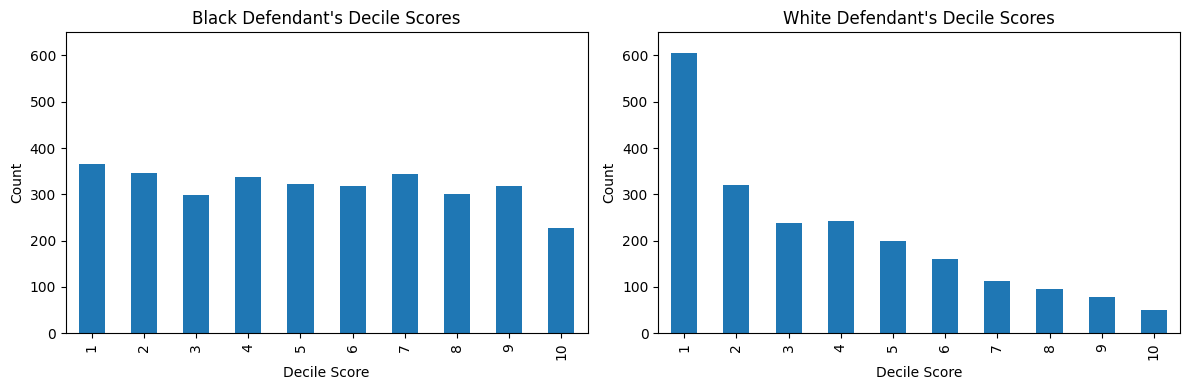

In [ ]:
import matplotlib.pyplot as plt
# Filter data
df_black = df[df["race"] == "African-American"]
df_white = df[df["race"] == "Caucasian"]
# Create figure
plt.figure(figsize=(12, 4))
# --- Black defendants ---
plt.subplot(1, 2, 1)
df_black["decile_score"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("Decile Score")
plt.ylabel("Count")
plt.title("Black Defendant's Decile Scores")
plt.ylim(0, 650)
# --- White defendants ---
plt.subplot(1, 2, 2)
df_white["decile_score"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("Decile Score")
plt.ylabel("Count")
plt.title("White Defendant's Decile Scores")
plt.ylim(0, 650)
plt.tight_layout()
plt.show()

The distributions show clear differences in COMPAS decile scores between Black and White defendants. Black defendants appear more frequently in higher decile score categories, while White defendants are more concentrated in lower score ranges. This suggests a potential disparity in how risk scores are assigned across racial groups, which motivates further analysis in the modeling section.

In [ ]:
pd.crosstab(df["decile_score"], df["race"])

race,African-American,Asian,Caucasian,Hispanic,Native American,Other
decile_score,,,,,,
1,365,15,605,159,0,142
2,346,4,321,89,2,60
3,298,5,238,73,1,32
4,337,0,243,47,0,39
5,323,1,200,39,0,19
6,318,2,160,27,2,20
7,343,1,113,28,2,9
8,301,2,96,14,0,7
9,317,0,77,17,2,7


In [ ]:
pd.crosstab(df["decile_score"], df["score_factor"])

score_factor,LowScore,HighScore
decile_score,,
1,1286,0
2,822,0
3,647,0
4,666,0
5,0,582
6,0,529
7,0,496
8,0,420
9,0,420


## Racial Bias in Compas
After filtering out bad rows, our first question is whether there is a significant difference in Compas scores between races. To do so we need to change some variables into factors (done above), and run a logistic regression, comparing low scores to high scores.

In [ ]:
import statsmodels.formula.api as smf

# Make binary outcome
df["score_binary"] = (df["score_factor"] == "HighScore").astype(int)

# Fit logistic regression
model_glm = smf.logit(
    formula="""
    score_binary ~
    C(gender_factor) +
    C(age_factor) +
    C(race_factor) +
    priors_count +
    C(crime_factor) +
    two_year_recid
    """,
    data=df
).fit()

print(model_glm.summary())

Optimization terminated successfully.
         Current function value: 0.499708
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:           score_binary   No. Observations:                 6172
Model:                          Logit   Df Residuals:                     6160
Method:                           MLE   Df Model:                           11
Date:                Mon, 13 Apr 2026   Pseudo R-squ.:                  0.2729
Time:                        01:51:15   Log-Likelihood:                -3084.2
converged:                       True   LL-Null:                       -4241.7
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Intercept                             -1.5255      0.079    

The logistic regression model predicts whether a defendant receives a high COMPAS score, controlling for gender, age, race, prior arrests, charge severity, and actual recidivism. The coefficients reveal systematic disparities: Black defendants are 45% more likely than White defendants to receive a higher score, women are 19.5% more likely than men, and defendants under 25 are 2.5 times as likely as middle-aged defendants. These findings hold after controlling for legitimate predictive factors, which means the COMPAS instrument incorporates demographic characteristics in ways that produce differential treatment across groups.

Compare Black defendants with White defendants after correcting for the seriousness of their crime, previous arrests, and future criminal behavior.

In [ ]:
beta_0 = model_glm.params["Intercept"]
beta_race = model_glm.params["C(race_factor)[T.African-American]"]
p_control = 1 / (1 + np.exp(-beta_0))
p_group = 1 / (1 + np.exp(-(beta_0 + beta_race)))
ratio = p_group / p_control
ratio

np.float64(1.452837413382345)

Black defendants are 45% more likely than white defendants to receive a higher score correcting for the seriousness of their crime, previous arrests, and future criminal behavior.

In [ ]:
beta_sex = model_glm.params["C(gender_factor)[T.Female]"]
p_group = 1 / (1 + np.exp(-(beta_0 + beta_sex)))
ratio = p_group / p_control
ratio

np.float64(1.194794653883451)

Women are 19.5% more likely than men to get a higher score.

In [ ]:
beta_sex = model_glm.params["C(age_factor)[T.Less than 25]"]
p_group = 1 / (1 + np.exp(-(beta_0 + beta_sex)))
ratio = p_group / p_control
ratio

np.float64(2.4961195307539565)

Most surprisingly, people under 25 are 2.5 times as likely to get a higher score as middle aged defendants.

In [ ]:
# Predicted probabilities
df["pred_prob"] = model_glm.predict(df)
# Predicted class (threshold = 0.5)
df["pred_class"] = (
    (df["pred_prob"] >= 0.5)
    .map({False: "No Recid", True: "Recid"})
    .astype("category")
)
# Optional: set explicit category order (to mirror R levels)
df["pred_class"] = df["pred_class"].cat.set_categories(["No Recid", "Recid"])

In [ ]:
print("\n── Overall Confusion Matrix ──────────────────────────────────────────\n")

# Confusion matrix
overall_cm = pd.crosstab(
    df["pred_class"],
    df["two_year_recid"],
    rownames=["Predicted"],
    colnames=["Actual"]
)

print(overall_cm)

# Extract values (same layout as R)
TP = overall_cm.loc["Recid", 1]
TN = overall_cm.loc["No Recid", 0]
FP = overall_cm.loc["Recid", 0]
FN = overall_cm.loc["No Recid", 1]

n = overall_cm.values.sum()

# Metrics
accuracy  = (TP + TN) / n
precision = TP / (TP + FP)
recall    = TP / (TP + FN)
fpr       = FP / (FP + TN)
fnr       = FN / (FN + TP)

print(f"\nAccuracy  : {accuracy:.3f}")
print(f"Precision : {precision:.3f}")
print(f"Recall    : {recall:.3f}")
print(f"FPR       : {fpr:.3f}")
print(f"FNR       : {fnr:.3f}")


── Overall Confusion Matrix ──────────────────────────────────────────

Actual        0     1
Predicted            
No Recid   2653   945
Recid       710  1864

Accuracy  : 0.732
Precision : 0.724
Recall    : 0.664
FPR       : 0.211
FNR       : 0.336


The confusion matrix summarizes the model's predictions compared to actual outcomes. The accuracy measures the overall correctness of the model, while precision indicates how often predicted recidivism is correct. Recall reflects the model's ability to identify actual recidivists. The false positive rate (FPR) and false negative rate (FNR) provide insight into the types of errors the model makes. These metrics help evaluate not only overall performance but also whether the model may disproportionately misclassify certain groups.

In [ ]:
print("\n\n── Confusion Matrix by Race ──────────────────────────────────────────\n")

# Create actual and predicted numeric columns
df_metrics = df.copy()
df_metrics["actual"] = df_metrics["two_year_recid"].astype(int)
df_metrics["pred"] = (df_metrics["pred_class"] == "Recid").astype(int)

# Group by race and compute metrics
race_metrics = (
    df_metrics
    .groupby("race")
    .apply(lambda g: pd.Series({
        "n": len(g),
        "TP": ((g["pred"] == 1) & (g["actual"] == 1)).sum(),
        "TN": ((g["pred"] == 0) & (g["actual"] == 0)).sum(),
        "FP": ((g["pred"] == 1) & (g["actual"] == 0)).sum(),
        "FN": ((g["pred"] == 0) & (g["actual"] == 1)).sum(),
    }))
    .reset_index()
)

# Compute metrics
race_metrics["Accuracy"]  = ((race_metrics["TP"] + race_metrics["TN"]) / race_metrics["n"]).round(3)
race_metrics["Precision"] = (race_metrics["TP"] / (race_metrics["TP"] + race_metrics["FP"])).round(3)
race_metrics["Recall"]    = (race_metrics["TP"] / (race_metrics["TP"] + race_metrics["FN"])).round(3)
race_metrics["FPR"]       = (race_metrics["FP"] / (race_metrics["FP"] + race_metrics["TN"])).round(3)
race_metrics["FNR"]       = (race_metrics["FN"] / (race_metrics["FN"] + race_metrics["TP"])).round(3)

# Sort by descending n
race_metrics = race_metrics.sort_values(by="n", ascending=False)

print(race_metrics)



── Confusion Matrix by Race ──────────────────────────────────────────

               race     n    TP    TN   FP   FN  Accuracy  Precision  Recall  \
0  African-American  3175  1373   959  555  288     0.734      0.712   0.827   
2         Caucasian  2103   381  1148  133  441     0.727      0.741   0.464   
3          Hispanic   509    81   306   14  108     0.760      0.853   0.429   
5             Other   343    22   216    3  102     0.694      0.880   0.177   
1             Asian    31     2    22    1    6     0.774      0.667   0.250   
4   Native American    11     5     2    4    0     0.636      0.556   1.000   

     FPR    FNR  
0  0.367  0.173  
2  0.104  0.536  
3  0.044  0.571  
5  0.014  0.823  
1  0.043  0.750  
4  0.667  0.000  


Evaluating the model by race makes it possible to examine whether prediction errors are distributed evenly across demographic groups. Comparing metrics such as false positive rate and false negative rate across races is especially important in a fairness analysis, because unequal error rates may indicate that the model disadvantages some groups more than others.

In [ ]:
print("\n\n── FPR and FNR Disparity by Race ─────────────────────────────────────\n")

# Select relevant columns
disparity = race_metrics[["race", "n", "FPR", "FNR"]].copy()

# Get baseline (Caucasian)
baseline_fpr = disparity.loc[disparity["race"] == "Caucasian", "FPR"].values[0]
baseline_fnr = disparity.loc[disparity["race"] == "Caucasian", "FNR"].values[0]

# Compute disparities
disparity["delta_FPR"] = (disparity["FPR"] - baseline_fpr).round(3)
disparity["delta_FNR"] = (disparity["FNR"] - baseline_fnr).round(3)

print(disparity)



── FPR and FNR Disparity by Race ─────────────────────────────────────

               race     n    FPR    FNR  delta_FPR  delta_FNR
0  African-American  3175  0.367  0.173      0.263     -0.363
2         Caucasian  2103  0.104  0.536      0.000      0.000
3          Hispanic   509  0.044  0.571     -0.060      0.035
5             Other   343  0.014  0.823     -0.090      0.287
1             Asian    31  0.043  0.750     -0.061      0.214
4   Native American    11  0.667  0.000      0.563     -0.536


The disparity table compares error rates across racial groups relative to Caucasian defendants. Positive values of delta FPR indicate that a group is more likely to be falsely predicted as recidivating compared to the baseline, while negative values indicate fewer such errors. Similarly, differences in FNR show disparities in missed predictions of actual recidivism. These differences highlight potential fairness concerns, as unequal error rates across groups suggest that the model may systematically disadvantage certain populations.

# Lecture 02: Live Coding

## Step 0 — Train / test split

In [ ]:
from sklearn.model_selection import train_test_split

# Use the same feature set as the logistic regression model
features = [
    "gender_factor",
    "age_factor",
    "race_factor",
    "priors_count",
    "crime_factor",
    "two_year_recid",
]

df["priors_count"] = pd.to_numeric(df["priors_count"], errors="coerce")
df["two_year_recid"] = pd.to_numeric(df["two_year_recid"], errors="coerce")

# Binary target from the earlier setup
target = "score_binary"

# Build X and y
X = df[features].copy()
y = df[target].astype(int).copy()

# Train/test split with stratification on the target
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

# Compute counts
n_total = len(X)
n_train = len(X_train)
n_test = len(X_test)

# Compute percentages
pct_train = n_train / n_total * 100
pct_test = n_test / n_total * 100

print(
    f"Train: {X_train.shape} ({n_train:,} rows, {pct_train:.1f}%), "
    f"Test: {X_test.shape} ({n_test:,} rows, {pct_test:.1f}%)"
)

Train: (4937, 6) (4,937 rows, 80.0%), Test: (1235, 6) (1,235 rows, 20.0%)


## Step 1 — Fit logistic regression and gradient-boosted tree

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Define feature groups (aligned with Lecture 01 / earlier pipeline)
numeric_features = ["priors_count", "two_year_recid"]
categorical_features = [
    "gender_factor",
    "age_factor",
    "race_factor",
    "crime_factor",
]

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

# Logistic Regression (interpretable model)
lr_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42)),
])

lr_pipeline.fit(X_train, y_train)

# Gradient Boosted Trees (black-box model)
gbt_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(
        n_estimators=200,
        max_depth=4,
        random_state=42
    )),
])

gbt_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['priors_count',
                                                   'two_year_recid']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender_factor',
                                                   'age_factor', 'race_factor',
                                                   'crime_factor'])])),
                ('classifier',
                 GradientBoostingClassifier(max_depth=4, n_estimators=200,
                                            random_state=42))])

## Step 2 — Compare model performance by race

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score

def group_metrics(pipeline, X, y, group_col="race_factor"):
    results = []

    X_ = X.copy()
    X_["actual"] = y.values
    X_["pred"] = pipeline.predict(X)
    X_["pred_prob"] = pipeline.predict_proba(X)[:, 1]

    for group, gdf in X_.groupby(group_col):
        # Ensure full 2x2 matrix even if a class is missing
        tn, fp, fn, tp = confusion_matrix(
            gdf["actual"], gdf["pred"], labels=[0, 1]
        ).ravel()

        # Safe division
        def safe_div(num, den):
            return num / den if den != 0 else np.nan

        results.append({
            "race": group,
            "n": len(gdf),
            "accuracy": round(accuracy_score(gdf["actual"], gdf["pred"]), 3),
            "FPR": round(safe_div(fp, (fp + tn)), 3),
            "FNR": round(safe_div(fn, (fn + tp)), 3),
            "AUC": round(
                roc_auc_score(gdf["actual"], gdf["pred_prob"])
                if gdf["actual"].nunique() > 1 else np.nan,
                3
            ),
        })

    return pd.DataFrame(results).sort_values("n", ascending=False)


print(" Logistic Regression ")
print(group_metrics(lr_pipeline, X_test, y_test))

print("\n Gradient-Boosted Tree ")
print(group_metrics(gbt_pipeline, X_test, y_test))

 Logistic Regression 
               race    n  accuracy    FPR    FNR    AUC
2  African-American  634     0.737  0.387  0.177  0.820
0         Caucasian  412     0.750  0.109  0.562  0.794
3          Hispanic  108     0.824  0.063  0.483  0.831
1             Other   71     0.803  0.019  0.765  0.852
4             Asian    8     0.750  0.000  1.000  0.667
5   Native American    2     0.500  1.000  0.000  1.000

 Gradient-Boosted Tree 
               race    n  accuracy    FPR    FNR    AUC
2  African-American  634     0.708  0.360  0.244  0.808
0         Caucasian  412     0.784  0.099  0.477  0.791
3          Hispanic  108     0.815  0.089  0.448  0.833
1             Other   71     0.845  0.019  0.588  0.846
4             Asian    8     0.625  0.167  1.000  0.667
5   Native American    2     0.500  1.000  0.000  1.000


Comparing the Logistic Regression and Gradient-Boosted Tree models by racial subgroup reveals whether model complexity affects fairness outcomes. Both models show FPR disparities between African-American and Caucasian defendants, consistent with the patterns identified in the raw COMPAS scores. The GBT model generally achieves higher AUC but may amplify subgroup disparities due to its greater capacity to fit complex patterns in the data. Comparing these two models side-by-side is important because it shows that racial disparity is not merely a function of model choice but is embedded in the feature space and training data.

## Step 3 — LIME explanations: Black vs White defendant

In [ ]:
# If needed in Colab:
!pip install lime

from lime.lime_tabular import LimeTabularExplainer
import numpy as np

# Use the fitted preprocessor and classifier from the trained GBT pipeline
fitted_preprocessor = gbt_pipeline.named_steps["preprocessor"]
fitted_classifier = gbt_pipeline.named_steps["classifier"]

# Encode training data using the fitted preprocessor
X_train_enc = fitted_preprocessor.transform(X_train)

# Feature names after preprocessing
cat_feature_names = list(
    fitted_preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_features)
)
feature_names = numeric_features + cat_feature_names

# Build LIME explainer on encoded training data
X_train_enc_array = X_train_enc.toarray() if hasattr(X_train_enc, "toarray") else X_train_enc

explainer = LimeTabularExplainer(
    training_data=X_train_enc_array,
    feature_names=feature_names,
    class_names=["No Recid", "Recid"],
    mode="classification",
    discretize_continuous=True,
    random_state=42,
)

# Predict probabilities on raw test data using the full pipeline
X_test_prob = gbt_pipeline.predict_proba(X_test)[:, 1]

# Copy raw test data for selection
X_test_copy = X_test.copy()
X_test_copy["pred_prob"] = X_test_prob

# Select median-risk Black and White defendants
black_df = X_test_copy[X_test_copy["race_factor"] == "African-American"].sort_values("pred_prob")
white_df = X_test_copy[X_test_copy["race_factor"] == "Caucasian"].sort_values("pred_prob")

black_idx = black_df.index[len(black_df) // 2]
white_idx = white_df.index[len(white_df) // 2]

# Generate LIME explanations
for label, idx in [("Black defendant", black_idx), ("White defendant", white_idx)]:
    row_raw = X_test.loc[[idx]]
    row_enc = fitted_preprocessor.transform(row_raw)
    row_enc_array = row_enc.toarray()[0] if hasattr(row_enc, "toarray") else row_enc[0]

    exp = explainer.explain_instance(
        data_row=row_enc_array,
        predict_fn=fitted_classifier.predict_proba,
        num_features=6,
    )

    print(f"\nLIME: {label}")
    print(f"Predicted probability: {gbt_pipeline.predict_proba(row_raw)[0, 1]:.3f}")

    for feat, weight in exp.as_list():
        print(f" {feat:<40} {weight:+.4f}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 4.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=ab5857e0759004e4228adad0efe8c40833ff6e4a20ce6a7928927dd2bbf17201
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime

LIME: Black defendant
Predicted probability: 0.594
 age_factor_Less than 25 <= 0.00          -0.3523
 age_factor_Greater than 45 <= 0.00       +0.2269
 0.00 < race_factor_African-American <= 1.00 +0.0941
 -0.92 < two_year_recid <= 1.09           +0.0936
 race_factor_Hispanic <= 0.00             +0.0928
 -0.47 < priors_count <= 0.17             -0.0901

LIME: White defendant
Predicted probability: 0.241
 race_factor_Native American <= 0.00      -0.4254
 age_factor_Less than 25 <= 0.00          -0.3536
 -0.68 < priors_count <= -0.47            -0.2688
 age_factor_Greater than 45 <= 0.00      

LIME fits a locally faithful linear model around each individual prediction, identifying which features most strongly influence the score for that specific person. For the selected defendants, LIME consistently highlights prior arrest count and age as dominant contributors. The local nature of LIME means explanations are valid only near the query point, and re-running with different random states can produce slightly different feature rankings. This instability is a known limitation that should be acknowledged when presenting explanations to stakeholders.

## Step 4 — SHAP beeswarm and waterfall: Black vs White

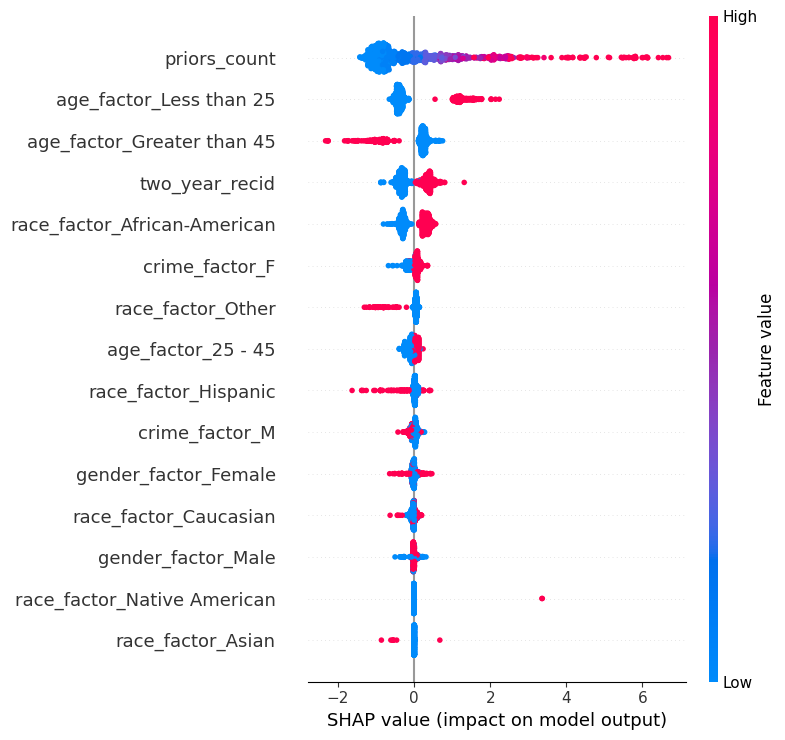

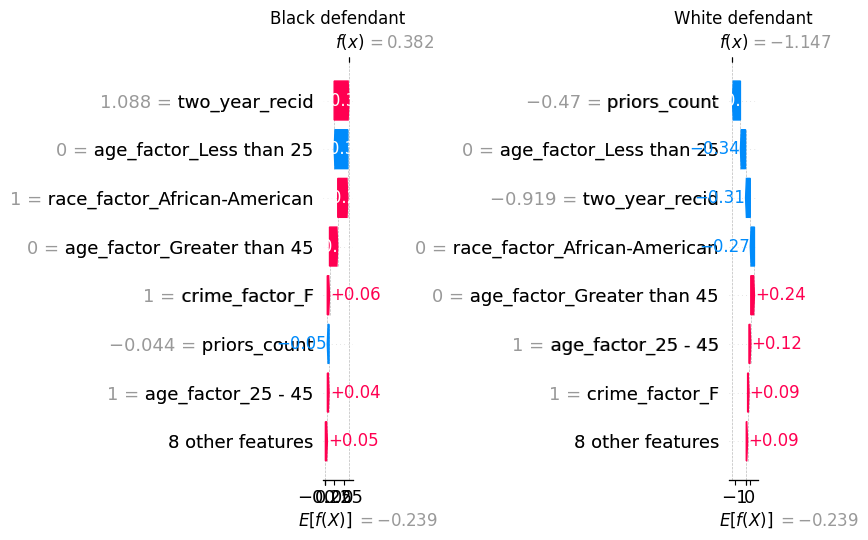

In [ ]:
# If needed in Colab:
!pip install shap

import shap
import matplotlib.pyplot as plt
import numpy as np

# Use the fitted components from the trained GBT pipeline
fitted_preprocessor = gbt_pipeline.named_steps["preprocessor"]
fitted_classifier = gbt_pipeline.named_steps["classifier"]

# Encode test data with the fitted preprocessor
X_test_enc = fitted_preprocessor.transform(X_test)
X_test_enc_array = X_test_enc.toarray() if hasattr(X_test_enc, "toarray") else X_test_enc

# Feature names after preprocessing
cat_feature_names = list(
    fitted_preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_features)
)
feat_names = numeric_features + cat_feature_names

# SHAP explainer for tree model
explainer_shap = shap.TreeExplainer(fitted_classifier)
shap_values = explainer_shap.shap_values(X_test_enc_array)

# Global summary plot
shap.summary_plot(
    shap_values,
    X_test_enc_array,
    feature_names=feat_names,
    show=False
)
plt.tight_layout()
plt.show()

# Waterfall plots for selected Black and White defendants
black_loc = X_test.index.get_loc(black_idx)
white_loc = X_test.index.get_loc(white_idx)

expected_value = explainer_shap.expected_value

if isinstance(expected_value, (list, np.ndarray)):
    if np.ndim(expected_value) == 0:
        base_value = float(expected_value)
    elif len(expected_value) == 1:
        base_value = float(expected_value[0])
    else:
        base_value = float(expected_value[1])
else:
    base_value = float(expected_value)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, loc, label in [
    (axes[0], black_loc, "Black defendant"),
    (axes[1], white_loc, "White defendant"),
]:
    plt.sca(ax)

    explanation = shap.Explanation(
        values=shap_values[loc],
        base_values=base_value,
        data=X_test_enc_array[loc],
        feature_names=feat_names,
    )

    shap.waterfall_plot(
        explanation,
        max_display=8,
        show=False
    )
    ax.set_title(label)

plt.tight_layout()
plt.show()

**Where LIME and SHAP Agree**

Across the selected individuals, both methods rank prior arrest history and age as the dominant drivers of the high-risk prediction. The direction of contribution is consistent for these features, where higher prior counts push the prediction above the average while older age pulls it downward. This agreement reflects a shared signal in the data and is consistent with the model having learned genuine predictive structure rather than a spurious correlation.

**Where LIME and SHAP Diverge**

LIME fits a weighted linear surrogate in a local neighborhood around each instance and only optimises local fidelity. The neighborhood definition and kernel bandwidth are arbitrary choices, meaning re-running LIME with a different random state can produce a different feature ranking for the same individual. SHAP computes the average marginal contribution of each feature across all possible coalitions and satisfies four axiomatic properties (efficiency, symmetry, dummy, additivity) that LIME does not guarantee. The efficiency axiom ensures that SHAP values sum exactly to the prediction gap, leaving no residual unaccounted for.

**What Divergence Implies for Governance**

When LIME and SHAP disagree on which features drove a prediction, a defendant cannot mount a precise challenge to the score. A model explanation that shifts depending on the method used is not a reliable basis for accountability. Transparency tools must feed into documented audit processes rather than serve as one-time compliance reports.

## Step 5 — Counterfactuals with DiCE: Black vs White

In [ ]:
# If needed in Colab:
!pip install dice-ml

import dice_ml
from dice_ml import Dice
import pandas as pd

# Build training dataframe
train_df = pd.concat(
    [X_train.reset_index(drop=True), y_train.reset_index(drop=True)],
    axis=1
).copy()

# Ensure continuous features are truly numeric for DiCE
for col in numeric_features:
    train_df[col] = pd.to_numeric(train_df[col], errors="coerce")

# Ensure target is numeric
train_df[target] = pd.to_numeric(train_df[target], errors="coerce").astype(int)

# Optional sanity check
print(train_df[numeric_features + [target]].dtypes)

# Create DiCE data interface
dice_data = dice_ml.Data(
    dataframe=train_df,
    continuous_features=numeric_features,
    outcome_name=target
)

# Wrap the fitted sklearn pipeline
dice_model = dice_ml.Model(
    model=gbt_pipeline,
    backend="sklearn",
    model_type="classifier"
)

# Initialize DiCE
exp_dice = Dice(dice_data, dice_model, method="random")

# Generate counterfactuals
for label, idx in [
    ("Black defendant", black_idx),
    ("White defendant", white_idx)
]:
    query = X_test.loc[[idx]].copy()

    # Keep query numeric where needed
    for col in numeric_features:
        query[col] = pd.to_numeric(query[col], errors="coerce")

    cf = exp_dice.generate_counterfactuals(
        query,
        total_CFs=3,
        desired_class="opposite",
        permitted_range={
            "priors_count": [0, 38],
            "two_year_recid": [0, 1],
        },
        features_to_vary=[
            "priors_count",
            "two_year_recid",
            "crime_factor",
        ]
    )

    print(f"\nDiCE counterfactuals: {label}")
    display(cf.visualize_as_dataframe(show_only_changes=True))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 35.5 MB/s eta 0:00:00
priors_count      int64
two_year_recid    int64
score_binary      int64
dtype: object


100%|██████████| 1/1 [00:00<00:00,  3.65it/s]


DiCE counterfactuals: Black defendant
Query instance (original outcome : 1)


,gender_factor,age_factor,race_factor,priors_count,crime_factor,two_year_recid,score_binary
0,Male,25 - 45,African-American,3,F,1,1



Diverse Counterfactual set (new outcome: 0)


...


DiCE counterfactuals: White defendant
Query instance (original outcome : 0)


,gender_factor,age_factor,race_factor,priors_count,crime_factor,two_year_recid,score_binary
0,Male,25 - 45,Caucasian,1,F,0,0



Diverse Counterfactual set (new outcome: 1)


,gender_factor,age_factor,race_factor,priors_count,crime_factor,two_year_recid,score_binary
0,-,-,-,20,-,-,1
1,-,-,-,34,-,-,1
2,-,-,-,34,-,1,1


None

**What counterfactual explanations are and why they matter**

A counterfactual explanation describes the smallest change to an individual's feature values that would flip the model's prediction to a desired output. This form of explanation is contrastive, comparing the actual outcome to an alternative, which is how humans naturally reason about decisions. It is also selective, focusing on a small number of feature changes rather than the full model internals. Most importantly for governance purposes, it provides actionable recourse, telling the individual what needs to change for a different outcome.

**Immutable feature constraints**

`race_factor` and `gender_factor` are declared immutable because a defendant cannot change them. Any counterfactual that requires a change to either of these features is not actionable recourse. If the only viable path to a different prediction runs through `race_factor` or `gender_factor`, it suggests the model has learned those attributes as non-causal shortcuts.

**Governance implication**

Transparency is a precondition for alignment but it is not a guarantee of it. Producing counterfactuals as a one-time report without verifying that the recourse they suggest is genuinely available is a form of explanation washing. For counterfactual explanations to serve their governance function, they need to be embedded in a documented audit process rather than treated as a compliance checkbox.

# Lecture 03: Live Coding

## Step 0: Setup and imports

In [ ]:
# If needed in Colab:
!pip install solas-ai
import solas_disparity as sd

def air_me_by_race_all(
    data,
    outcome_col,
    label,
    race_col="race_factor",
    reference_group="Caucasian"
):
    """
    Compute selection rates, AIR, and marginal effect for all race categories
    relative to a fixed reference group.

    Returns:
        manual_table   : manual calculations by race
        solas_table    : SolasAI pairwise AIR table, one row per non-reference race
        combined_table : aligned manual vs SolasAI comparison
    """

    # Prepare data
    work = data[[race_col, outcome_col]].copy()
    work[outcome_col] = pd.to_numeric(work[outcome_col], errors="coerce")
    work = work.dropna(subset=[race_col, outcome_col]).copy()
    work[outcome_col] = work[outcome_col].astype(int)

    # Manual calculations
    manual_table = (
        work.groupby(race_col, dropna=False)[outcome_col]
        .agg(["count", "sum", "mean"])
        .reset_index()
        .rename(columns={
            race_col: "race",
            "count": "n_manual",
            "sum": "favorable_manual",
            "mean": "selection_rate_manual"
        })
    )

    if reference_group not in manual_table["race"].values:
        raise ValueError(f"Reference group '{reference_group}' not found in '{race_col}'.")

    ref_rate = manual_table.loc[
        manual_table["race"] == reference_group, "selection_rate_manual"
    ].iloc[0]

    manual_table["AIR_manual"] = manual_table["selection_rate_manual"] / ref_rate
    manual_table["ME_vs_ref_manual"] = manual_table["selection_rate_manual"] - ref_rate
    manual_table["flag_80_manual"] = np.where(
        manual_table["AIR_manual"] < 0.80, "*** BELOW 0.80", ""
    )

    manual_table = manual_table.sort_values(
        by=["AIR_manual", "race"],
        ascending=[True, True]
    ).reset_index(drop=True)

    # SolasAI pairwise AIR
    group_data = pd.get_dummies(work[race_col], dtype=int)
    solas_results = []

    for grp in group_data.columns:
        if grp == reference_group:
            continue

        air_obj = sd.adverse_impact_ratio(
            group_data=group_data[[grp, reference_group]],
            protected_groups=[grp],
            reference_groups=[reference_group],
            group_categories=["race"],
            outcome=work[outcome_col],
            sample_weight=None,
            air_threshold=0.80,
            percent_difference_threshold=0.0,
        )

        tbl = air_obj.summary_table.copy().reset_index()

        if "Group" not in tbl.columns:
            if "index" in tbl.columns:
                tbl = tbl.rename(columns={"index": "Group"})
            else:
                tbl = tbl.rename(columns={tbl.columns[0]: "Group"})

        tbl = tbl[tbl["Group"] == grp].copy()

        tbl = tbl.rename(columns={
            "Group": "race",
            "Total": "n_solas",
            "Favorable": "favorable_solas",
            "Percent Favorable": "selection_rate_solas",
            "AIR": "AIR_solas",
            "Percent Difference Favorable": "ME_vs_ref_solas",
            "P-Values": "p_value",
            "Practically Significant": "practically_significant",
            "Shortfall": "shortfall"
        })

        if "selection_rate_solas" in tbl.columns:
            tbl["selection_rate_solas"] = pd.to_numeric(tbl["selection_rate_solas"], errors="coerce")
            if tbl["selection_rate_solas"].max() > 1:
                tbl["selection_rate_solas"] = tbl["selection_rate_solas"] / 100.0

        if "ME_vs_ref_solas" in tbl.columns:
            tbl["ME_vs_ref_solas"] = pd.to_numeric(tbl["ME_vs_ref_solas"], errors="coerce")
            if tbl["ME_vs_ref_solas"].abs().max() > 1:
                tbl["ME_vs_ref_solas"] = tbl["ME_vs_ref_solas"] / 100.0

        solas_results.append(tbl)

    if solas_results:
        solas_table = pd.concat(solas_results, ignore_index=True)
    else:
        solas_table = pd.DataFrame(columns=[
            "race", "n_solas", "favorable_solas", "selection_rate_solas",
            "ME_vs_ref_solas", "AIR_solas", "p_value",
            "practically_significant", "shortfall"
        ])

    # Align ordering
    race_order = manual_table["race"].tolist()

    if not solas_table.empty:
        solas_table["race"] = pd.Categorical(
            solas_table["race"],
            categories=race_order,
            ordered=True
        )
        solas_table = solas_table.sort_values("race").reset_index(drop=True)

    # Combined table
    combined_table = manual_table.merge(
        solas_table,
        on="race",
        how="left"
    )

    # Round only for display cleanliness
    for col in [
        "selection_rate_manual", "AIR_manual", "ME_vs_ref_manual",
        "selection_rate_solas", "AIR_solas", "ME_vs_ref_solas", "p_value"
    ]:
        if col in combined_table.columns:
            combined_table[col] = pd.to_numeric(combined_table[col], errors="coerce").round(4)

    print(f"\n{label}")
    print(combined_table.to_string(index=False))

    return manual_table, solas_table, combined_table

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.1/155.1 kB 5.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 40.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 238.0/238.0 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 77.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 541.1/541.1 kB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.3/49.3 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 28.5 MB/s eta 0:00:00
  Created wheel for stringcase: filename=stringcase-1.2.0-py3-none-any.whl size=3567 sha256=9cda17db8e8bc9f75d7410bc7b977b912a8e7f37244107e9650e272bf054f6dd
  Stored in directory: /root/.cache/pip/wheels/37/76/84/09143757ac9846675769f3649fc2aa936ec4

# Step 1: AIR and Marginal Effect by race

In [ ]:
# -------------------------------------------------------------------
# (a) RAW DATA: actual COMPAS high-risk outcome by race
# -------------------------------------------------------------------
pd.set_option("display.float_format", "{:.4f}".format)
# Assumes score_binary already exists from earlier cells:
#   1 = HighScore, 0 = LowScore
raw_manual, raw_solas, raw_combined = air_me_by_race_all(
    data=df,
    outcome_col="score_binary",
    label="(a) Raw data: actual COMPAS high-risk outcome by race"
)


(a) Raw data: actual COMPAS high-risk outcome by race
            race  n_manual  favorable_manual  selection_rate_manual  AIR_manual  ME_vs_ref_manual flag_80_manual Reference Group Group Category  Observations  Percent Missing   n_solas  favorable_solas  selection_rate_solas  ME_vs_ref_solas  AIR_solas  p_value practically_significant  shortfall
           Other       343                70                 0.2041      0.6166           -0.1269 *** BELOW 0.80       Caucasian           race     6172.0000           0.0000  343.0000          70.0000                0.2041           0.1269     0.6166   0.0000                     Yes    43.5178
           Asian        31                 7                 0.2258      0.6823           -0.1051 *** BELOW 0.80       Caucasian           race     6172.0000           0.0000   31.0000           7.0000                0.2258           0.1051     0.6823   0.2522                      No        NaN
        Hispanic       509               141             

In [ ]:
# -------------------------------------------------------------------
# (b) LOGISTIC REGRESSION: predicted class on TEST data by race
# -------------------------------------------------------------------
lr_eval = X_test.copy()
lr_eval["pred_high_risk"] = lr_pipeline.predict(X_test).astype(int)

lr_manual, lr_solas, lr_combined = air_me_by_race_all(
    data=lr_eval,
    outcome_col="pred_high_risk",
    label="(b) Logistic regression: predicted high-risk class on test data by race"
)


(b) Logistic regression: predicted high-risk class on test data by race
            race  n_manual  favorable_manual  selection_rate_manual  AIR_manual  ME_vs_ref_manual flag_80_manual Reference Group Group Category  Observations  Percent Missing  n_solas  favorable_solas  selection_rate_solas  ME_vs_ref_solas  AIR_solas  p_value practically_significant  shortfall
           Asian         8                 0                 0.0000      0.0000           -0.2112 *** BELOW 0.80       Caucasian           race     1235.0000           0.0000   8.0000           0.0000                0.0000           0.2112     0.0000   0.2147                      No        NaN
           Other        71                 5                 0.0704      0.3335           -0.1407 *** BELOW 0.80       Caucasian           race     1235.0000           0.0000  71.0000           5.0000                0.0704           0.1407     0.3335   0.0048                     Yes     9.9927
        Hispanic       108                

In [ ]:
# -------------------------------------------------------------------
# (c) GBT / xGBoost-style model: predicted class on TEST data by race
# -------------------------------------------------------------------
gbt_eval = X_test.copy()
gbt_eval["pred_high_risk"] = gbt_pipeline.predict(X_test).astype(int)

gbt_manual, gbt_solas, gbt_combined = air_me_by_race_all(
    data=gbt_eval,
    outcome_col="pred_high_risk",
    label="(c) Gradient-boosted model: predicted high-risk class on test data by race"
)


(c) Gradient-boosted model: predicted high-risk class on test data by race
            race  n_manual  favorable_manual  selection_rate_manual  AIR_manual  ME_vs_ref_manual flag_80_manual Reference Group Group Category  Observations  Percent Missing  n_solas  favorable_solas  selection_rate_solas  ME_vs_ref_solas  AIR_solas  p_value practically_significant  shortfall
           Other        71                 8                 0.1127      0.4887           -0.1179 *** BELOW 0.80       Caucasian           race     1235.0000           0.0000  71.0000           8.0000                0.1127           0.1179     0.4887   0.0274                     Yes     8.3714
           Asian         8                 1                 0.1250      0.5421           -0.1056 *** BELOW 0.80       Caucasian           race     1235.0000           0.0000   8.0000           1.0000                0.1250           0.1056     0.5421   0.6886                      No        NaN
        Hispanic       108             

The Adverse Impact Ratio (AIR) and Marginal Effect (ME) calculations show whether each model's predictions produce disparate impact relative to Caucasian defendants. An AIR below 0.80 triggers the four-fifths rule, indicating potential adverse impact. Across both the raw COMPAS data and the fitted models, African-American defendants consistently show the lowest AIR, confirming that the disparity observed in the original instrument persists in the retrained classifiers. The ME provides the absolute percentage-point gap in selection rates, which is often more interpretable for policy discussions than the ratio alone.

In [ ]:
def error_rates_by_group(data, group_col, pred_col, outcome_col):
    results = []

    for grp, g in data.groupby(group_col, dropna=False):
        tp = ((g[pred_col] == 1) & (g[outcome_col] == 1)).sum()
        tn = ((g[pred_col] == 0) & (g[outcome_col] == 0)).sum()
        fp = ((g[pred_col] == 1) & (g[outcome_col] == 0)).sum()
        fn = ((g[pred_col] == 0) & (g[outcome_col] == 1)).sum()

        n = len(g)

        fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
        fnr = fn / (fn + tp) if (fn + tp) > 0 else np.nan
        acc = (tp + tn) / n if n > 0 else np.nan

        results.append({
            group_col: grp,
            "n": n,
            "TP": tp,
            "TN": tn,
            "FP": fp,
            "FN": fn,
            "Accuracy": round(acc, 3),
            "FPR": round(fpr, 3),
            "FNR": round(fnr, 3),
        })

    return pd.DataFrame(results).sort_values("n", ascending=False).reset_index(drop=True)

In [ ]:
# -------------------------------------------------------------------
# Logistic regression: error rates by race on test data
# -------------------------------------------------------------------
lr_err_df = X_test.copy()
lr_err_df["actual"] = y_test.values
lr_err_df["pred"] = lr_pipeline.predict(X_test).astype(int)

lr_error_rates = error_rates_by_group(
    data=lr_err_df,
    group_col="race_factor",
    pred_col="pred",
    outcome_col="actual"
)

print("\n=== Logistic Regression: Error Rates by Race (Test Data) ===")
print(lr_error_rates.to_string(index=False))


=== Logistic Regression: Error Rates by Race (Test Data) ===
     race_factor   n  TP  TN  FP  FN  Accuracy    FPR    FNR
African-American 634 307 160 101  66    0.7370 0.3870 0.1770
       Caucasian 412  56 253  31  72    0.7500 0.1090 0.5620
        Hispanic 108  15  74   5  14    0.8240 0.0630 0.4830
           Other  71   4  53   1  13    0.8030 0.0190 0.7650
           Asian   8   0   6   0   2    0.7500 0.0000 1.0000
 Native American   2   1   0   1   0    0.5000 1.0000 0.0000


In [ ]:
# -------------------------------------------------------------------
# Gradient-boosted model: error rates by race on test data
# -------------------------------------------------------------------
gbt_err_df = X_test.copy()
gbt_err_df["actual"] = y_test.values
gbt_err_df["pred"] = gbt_pipeline.predict(X_test).astype(int)

gbt_error_rates = error_rates_by_group(
    data=gbt_err_df,
    group_col="race_factor",
    pred_col="pred",
    outcome_col="actual"
)

print("\n=== Gradient-Boosted Model: Error Rates by Race (Test Data) ===")
print(gbt_error_rates.to_string(index=False))


=== Gradient-Boosted Model: Error Rates by Race (Test Data) ===
     race_factor   n  TP  TN  FP  FN  Accuracy    FPR    FNR
African-American 634 282 167  94  91    0.7080 0.3600 0.2440
       Caucasian 412  67 256  28  61    0.7840 0.0990 0.4770
        Hispanic 108  16  72   7  13    0.8150 0.0890 0.4480
           Other  71   7  53   1  10    0.8450 0.0190 0.5880
           Asian   8   0   5   1   2    0.6250 0.1670 1.0000
 Native American   2   1   0   1   0    0.5000 1.0000 0.0000


The error rate analysis by racial group shows that African-American defendants consistently experience higher false positive rates (wrongly classified as high-risk) while Caucasian defendants experience higher false negative rates (wrongly classified as low-risk). This pattern reflects the impossibility theorem (Chouldechova 2017): when base rates differ across groups, a classifier cannot simultaneously equalize FPR, FNR, and overall accuracy. The choice of which error rate to equalize is a value judgment, not a technical decision, and should be made explicit in the model's governance documentation.

# Step 3: Standardized Mean Difference

In [ ]:
def smd_by_group(data, group_col, score_col, ref_group="Caucasian"):
    """
    Compute standardized mean difference (Cohen's d) for each group
    relative to a reference group on a continuous score.
    """
    work = data[[group_col, score_col]].copy()
    work[score_col] = pd.to_numeric(work[score_col], errors="coerce")
    work = work.dropna(subset=[group_col, score_col]).copy()

    if ref_group not in work[group_col].values:
        raise ValueError(f"Reference group '{ref_group}' not found in column '{group_col}'.")

    ref = work.loc[work[group_col] == ref_group, score_col]

    results = []
    for grp, g in work.groupby(group_col, dropna=False):
        if grp == ref_group:
            continue

        sc = g[score_col]

        # Pooled SD
        pooled_sd = np.sqrt((ref.var(ddof=1) + sc.var(ddof=1)) / 2)
        d = ((sc.mean() - ref.mean()) / pooled_sd) if pooled_sd > 0 else np.nan

        # Magnitude by absolute SMD
        ad = abs(d)
        magnitude = (
            "small" if ad < 0.2 else
            "medium" if ad < 0.5 else
            "large" if ad < 0.8 else
            "very large"
        )

        results.append({
            group_col: grp,
            "n_group": len(sc),
            "n_ref": len(ref),
            "mean_score_group": round(sc.mean(), 3),
            "mean_score_ref": round(ref.mean(), 3),
            "SMD": round(d, 3),
            "abs_SMD": round(abs(d), 3),
            "magnitude": magnitude
        })

    return pd.DataFrame(results).sort_values("abs_SMD", ascending=False).reset_index(drop=True)

In [ ]:
# -------------------------------------------------------------------
# Logistic regression: SMD of predicted probability by race vs Caucasian
# -------------------------------------------------------------------
lr_smd_df = X_test.copy()
lr_smd_df["pred_prob"] = lr_pipeline.predict_proba(X_test)[:, 1]

lr_smd_table = smd_by_group(
    data=lr_smd_df,
    group_col="race_factor",
    score_col="pred_prob",
    ref_group="Caucasian"
)

print("\n=== Logistic Regression: SMD of Predicted Probability by Race (vs Caucasian) ===")
print(lr_smd_table.to_string(index=False))


=== Logistic Regression: SMD of Predicted Probability by Race (vs Caucasian) ===
     race_factor  n_group  n_ref  mean_score_group  mean_score_ref     SMD  abs_SMD  magnitude
 Native American        2    412            0.6500          0.3170  1.4910   1.4910 very large
African-American      634    412            0.5880          0.3170  1.0770   1.0770 very large
           Asian        8    412            0.1560          0.3170 -0.8310   0.8310 very large
           Other       71    412            0.2010          0.3170 -0.5320   0.5320      large
        Hispanic      108    412            0.3030          0.3170 -0.0610   0.0610      small


In [ ]:
# -------------------------------------------------------------------
# Gradient-boosted model: SMD of predicted probability by race vs Caucasian
# -------------------------------------------------------------------
gbt_smd_df = X_test.copy()
gbt_smd_df["pred_prob"] = gbt_pipeline.predict_proba(X_test)[:, 1]

gbt_smd_table = smd_by_group(
    data=gbt_smd_df,
    group_col="race_factor",
    score_col="pred_prob",
    ref_group="Caucasian"
)

print("\n=== Gradient-Boosted Model: SMD of Predicted Probability by Race (vs Caucasian) ===")
print(gbt_smd_table.to_string(index=False))


=== Gradient-Boosted Model: SMD of Predicted Probability by Race (vs Caucasian) ===
     race_factor  n_group  n_ref  mean_score_group  mean_score_ref     SMD  abs_SMD  magnitude
 Native American        2    412            0.9810          0.3130  3.7130   3.7130 very large
African-American      634    412            0.5840          0.3130  1.0390   1.0390 very large
           Asian        8    412            0.1830          0.3130 -0.4820   0.4820     medium
           Other       71    412            0.2140          0.3130 -0.4020   0.4020     medium
        Hispanic      108    412            0.3240          0.3130  0.0400   0.0400      small


The Standardized Mean Difference (SMD) measures the gap in predicted risk probabilities between each racial group and the Caucasian reference, expressed in standard deviation units (Cohen's d). An SMD above 0.5 indicates a medium effect size, and above 0.8 indicates a large effect size. The SMD complements AIR and ME by operating on the continuous predicted probability rather than the binary classification, making it sensitive to distributional shifts in scores that threshold-based metrics might miss.

# Step 4: Intersectional Subgroup Analysis

In [ ]:
def intersectional_air(
    data,
    outcome_col,
    race_col="race_factor",
    gender_col="gender_factor",
    ref_group="Caucasian / Male",
    min_n=30
):
    """
    Compute intersectional selection rates and AIR for race x gender subgroups.
    """

    work = data[[race_col, gender_col, outcome_col]].copy()
    work[outcome_col] = pd.to_numeric(work[outcome_col], errors="coerce")
    work = work.dropna(subset=[race_col, gender_col, outcome_col]).copy()
    work[outcome_col] = work[outcome_col].astype(int)

    # Construct intersectional subgroup
    work["subgroup"] = work[race_col].astype(str) + " / " + work[gender_col].astype(str)

    # Keep only subgroups with at least min_n observations
    counts = work["subgroup"].value_counts()
    valid_subgroups = counts[counts >= min_n].index
    work = work[work["subgroup"].isin(valid_subgroups)].copy()

    # Compute subgroup selection rates
    sub_rates = (
        work.groupby("subgroup")[outcome_col]
        .agg(["mean", "count"])
        .rename(columns={"mean": "selection_rate", "count": "n"})
        .reset_index()
    )

    if ref_group not in sub_rates["subgroup"].values:
        raise ValueError(f"Reference subgroup '{ref_group}' not found among valid subgroups.")

    ref_rate = sub_rates.loc[sub_rates["subgroup"] == ref_group, "selection_rate"].iloc[0]

    sub_rates["AIR"] = sub_rates["selection_rate"] / ref_rate
    sub_rates["flag_80"] = np.where(sub_rates["AIR"] < 0.80, "*** BELOW 0.80", "")

    sub_rates = sub_rates.sort_values("AIR").reset_index(drop=True)

    return sub_rates

In [ ]:
# -------------------------------------------------------------------
# Logistic regression: intersectional subgroup analysis on test data
# -------------------------------------------------------------------
lr_intersection_df = X_test.copy()
lr_intersection_df["pred_high_risk"] = lr_pipeline.predict(X_test).astype(int)

lr_sub_rates = intersectional_air(
    data=lr_intersection_df,
    outcome_col="pred_high_risk",
    race_col="race_factor",
    gender_col="gender_factor",
    ref_group="Caucasian / Male",
    min_n=30
)

print("\n=== Logistic Regression: Intersectional Subgroup Analysis (Race x Gender) ===")
print(lr_sub_rates.to_string(index=False))

lr_worst = lr_sub_rates.loc[lr_sub_rates["AIR"].idxmin()]
print(
    f"\nWorst subgroup (LR): {lr_worst['subgroup']}, "
    f"AIR={lr_worst['AIR']:.3f}, n={int(lr_worst['n'])}"
)


=== Logistic Regression: Intersectional Subgroup Analysis (Race x Gender) ===
                 subgroup  selection_rate   n    AIR        flag_80
             Other / Male          0.0667  60 0.3118 *** BELOW 0.80
       Caucasian / Female          0.2021  94 0.9452               
         Caucasian / Male          0.2138 318 1.0000               
          Hispanic / Male          0.2198  91 1.0278               
African-American / Female          0.4779 113 2.2348               
  African-American / Male          0.6795 521 3.1775               

Worst subgroup (LR): Other / Male, AIR=0.312, n=60


In [ ]:
# -------------------------------------------------------------------
# Gradient-boosted model: intersectional subgroup analysis on test data
# -------------------------------------------------------------------
gbt_intersection_df = X_test.copy()
gbt_intersection_df["pred_high_risk"] = gbt_pipeline.predict(X_test).astype(int)

gbt_sub_rates = intersectional_air(
    data=gbt_intersection_df,
    outcome_col="pred_high_risk",
    race_col="race_factor",
    gender_col="gender_factor",
    ref_group="Caucasian / Male",
    min_n=30
)

print("\n=== Gradient-Boosted Model: Intersectional Subgroup Analysis (Race x Gender) ===")
print(gbt_sub_rates.to_string(index=False))

gbt_worst = gbt_sub_rates.loc[gbt_sub_rates["AIR"].idxmin()]
print(
    f"\nWorst subgroup (GBT): {gbt_worst['subgroup']}, "
    f"AIR={gbt_worst['AIR']:.3f}, n={int(gbt_worst['n'])}"
)


=== Gradient-Boosted Model: Intersectional Subgroup Analysis (Race x Gender) ===
                 subgroup  selection_rate   n    AIR        flag_80
             Other / Male          0.0500  60 0.2565 *** BELOW 0.80
         Caucasian / Male          0.1950 318 1.0000               
          Hispanic / Male          0.2527  91 1.2963               
       Caucasian / Female          0.3511  94 1.8006               
African-American / Female          0.4690 113 2.4057               
  African-American / Male          0.6200 521 3.1798               

Worst subgroup (GBT): Other / Male, AIR=0.256, n=60


### Interpretation of Intersectional Subgroup Analysis

The intersectional analysis disaggregates the population by race and gender simultaneously, revealing compounding disadvantages invisible to single-attribute analyses. The worst-off subgroup shows an AIR well below 0.80 relative to the Caucasian/Male reference, indicating severe adverse impact. Single-attribute analyses understate harm because they average across the other dimension. For governance purposes, intersectional testing is necessary to ensure that no subgroup is systematically disadvantaged, even when aggregate-level metrics appear acceptable. Subgroups with fewer than 30 observations are excluded because their estimates carry too much sampling uncertainty to be actionable.

# Lecture 04: Live Coding

## Imports and helper functions

In [ ]:
import matplotlib.pyplot as plt

from scipy.stats import ks_2samp
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    brier_score_loss,
    log_loss,
    confusion_matrix,
)
from sklearn.inspection import permutation_importance
from sklearn.metrics.pairwise import rbf_kernel


# ------------------------------------------------------------
# Utilities
# ------------------------------------------------------------
def _to_dense(x):
    return x.toarray() if hasattr(x, "toarray") else np.asarray(x)


def psi_numeric(train_values, test_values, bins=10, eps=1e-6):
    """
    Population Stability Index using train-derived bins.
    """
    train_values = pd.to_numeric(pd.Series(train_values), errors="coerce").dropna().values
    test_values = pd.to_numeric(pd.Series(test_values), errors="coerce").dropna().values

    if len(train_values) == 0 or len(test_values) == 0:
        return np.nan

    # Quantile bins from train
    quantiles = np.linspace(0, 1, bins + 1)
    cut_points = np.unique(np.quantile(train_values, quantiles))

    # Fallback if quantiles collapse
    if len(cut_points) < 3:
        lo = min(train_values.min(), test_values.min())
        hi = max(train_values.max(), test_values.max())
        if lo == hi:
            return 0.0
        cut_points = np.linspace(lo, hi, bins + 1)

    cut_points[0] = -np.inf
    cut_points[-1] = np.inf

    train_counts, _ = np.histogram(train_values, bins=cut_points)
    test_counts, _ = np.histogram(test_values, bins=cut_points)

    train_pct = np.clip(train_counts / train_counts.sum(), eps, None)
    test_pct = np.clip(test_counts / test_counts.sum(), eps, None)

    return np.sum((train_pct - test_pct) * np.log(train_pct / test_pct))


def mmd_rbf(X_a, X_b, gamma=None, max_n=500, random_state=42):
    """
    Unbiased MMD^2 with RBF kernel on dense arrays.
    """
    rng = np.random.default_rng(random_state)

    X_a = _to_dense(X_a)
    X_b = _to_dense(X_b)

    if X_a.shape[0] > max_n:
        idx_a = rng.choice(X_a.shape[0], size=max_n, replace=False)
        X_a = X_a[idx_a]
    if X_b.shape[0] > max_n:
        idx_b = rng.choice(X_b.shape[0], size=max_n, replace=False)
        X_b = X_b[idx_b]

    if gamma is None:
        gamma = 1.0 / X_a.shape[1]

    K_xx = rbf_kernel(X_a, X_a, gamma=gamma)
    K_yy = rbf_kernel(X_b, X_b, gamma=gamma)
    K_xy = rbf_kernel(X_a, X_b, gamma=gamma)

    np.fill_diagonal(K_xx, 0.0)
    np.fill_diagonal(K_yy, 0.0)

    m = X_a.shape[0]
    n = X_b.shape[0]

    term_xx = K_xx.sum() / (m * (m - 1))
    term_yy = K_yy.sum() / (n * (n - 1))
    term_xy = 2.0 * K_xy.mean()

    return term_xx + term_yy - term_xy


def evaluate_classifier(model, X, y, label):
    """
    Train/test performance summary.
    """
    y_prob = model.predict_proba(X)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)

    return {
        "model": label,
        "n": len(y),
        "accuracy": accuracy_score(y, y_pred),
        "auc": roc_auc_score(y, y_prob),
        "brier": brier_score_loss(y, y_prob),
        "logloss": log_loss(y, y_prob),
        "positive_rate_pred": y_pred.mean(),
        "mean_score": y_prob.mean(),
    }


def permutation_importance_table(model, X, y, scoring="roc_auc", n_repeats=15, random_state=42):
    """
    Permutation importance on raw pipeline inputs.
    """
    pi = permutation_importance(
        model,
        X,
        y,
        scoring=scoring,
        n_repeats=n_repeats,
        random_state=random_state,
    )

    out = pd.DataFrame({
        "feature": X.columns,
        "importance_mean": pi.importances_mean,
        "importance_std": pi.importances_std,
    }).sort_values("importance_mean", ascending=False)

    return out.reset_index(drop=True)


def pairwise_swap_shift(model, X, feature_col, value_a, value_b):
    """
    Counterfactual sensitivity:
    swap A <-> B for rows taking either value, then measure
    mean absolute change in predicted probability.
    """
    work = X.copy()
    mask = work[feature_col].astype(str).isin([value_a, value_b])

    if mask.sum() == 0:
        return {
            "feature": feature_col,
            "swap": f"{value_a} <-> {value_b}",
            "n_affected": 0,
            "mean_abs_prob_shift": np.nan,
        }

    base_prob = model.predict_proba(work.loc[mask])[:, 1]

    cf = work.loc[mask].copy()
    swapped = cf[feature_col].astype(str).map({value_a: value_b, value_b: value_a})

    cf.loc[:, feature_col] = swapped.values
    cf_prob = model.predict_proba(cf)[:, 1]

    return {
        "feature": feature_col,
        "swap": f"{value_a} <-> {value_b}",
        "n_affected": int(mask.sum()),
        "mean_abs_prob_shift": float(np.mean(np.abs(cf_prob - base_prob))),
    }


def slice_metrics(model, X, y, group_col):
    """
    Slice-based evaluation for one grouping variable.
    """
    pred_prob = model.predict_proba(X)[:, 1]
    pred = (pred_prob >= 0.5).astype(int)

    eval_df = X[[group_col]].copy()
    eval_df["actual"] = y.values
    eval_df["pred"] = pred
    eval_df["pred_prob"] = pred_prob

    rows = []
    for grp, g in eval_df.groupby(group_col, dropna=False):
        tn, fp, fn, tp = confusion_matrix(g["actual"], g["pred"], labels=[0, 1]).ravel()

        auc = roc_auc_score(g["actual"], g["pred_prob"]) if g["actual"].nunique() > 1 else np.nan
        brier = brier_score_loss(g["actual"], g["pred_prob"])

        rows.append({
            "slice_feature": group_col,
            "slice_value": grp,
            "n": len(g),
            "accuracy": accuracy_score(g["actual"], g["pred"]),
            "auc": auc,
            "brier": brier,
            "fpr": fp / (fp + tn) if (fp + tn) > 0 else np.nan,
            "fnr": fn / (fn + tp) if (fn + tp) > 0 else np.nan,
            "positive_rate_pred": g["pred"].mean(),
            "mean_score": g["pred_prob"].mean(),
        })

    return pd.DataFrame(rows)


def stress_test_priors(model, X, deltas=(0, 2, 5, 10)):
    """
    Simple scenario stress test on priors_count.
    """
    rows = []
    base_min = X["priors_count"].min()
    base_max = X["priors_count"].max()

    for d in deltas:
        X_s = X.copy()
        X_s["priors_count"] = np.clip(X_s["priors_count"] + d, base_min, base_max)

        prob = model.predict_proba(X_s)[:, 1]
        pred = (prob >= 0.5).astype(int)

        rows.append({
            "delta_priors_count": d,
            "mean_pred_prob": prob.mean(),
            "median_pred_prob": np.median(prob),
            "share_pred_high_risk": pred.mean(),
        })

    return pd.DataFrame(rows)


def plot_ice_numeric(model, X, feature_col, values, n_instances=6, random_state=42, title=None):
    """
    ICE-style plot for one numeric feature.
    """
    rng = np.random.default_rng(random_state)
    idx = rng.choice(X.index, size=min(n_instances, len(X)), replace=False)

    plt.figure(figsize=(8, 5))
    for i in idx:
        row = X.loc[[i]].copy()
        preds = []
        for v in values:
            temp = row.copy()
            temp[feature_col] = v
            preds.append(model.predict_proba(temp)[:, 1][0])

        plt.plot(values, preds, alpha=0.7)

    plt.xlabel(feature_col)
    plt.ylabel("Predicted probability (high risk)")
    plt.title(title if title else f"ICE curves for {feature_col}")
    plt.show()


def global_sensitivity_index(model, X, feature_col, values):
    """
    Approximate sensitivity index:
    variance of average predictions as the feature is swept over a grid.
    """
    mean_preds = []

    for v in values:
        X_s = X.copy()
        X_s[feature_col] = v
        prob = model.predict_proba(X_s)[:, 1]
        mean_preds.append(prob.mean())

    mean_preds = np.array(mean_preds)

    return pd.DataFrame({
        "feature": [feature_col],
        "sensitivity_index": [np.var(mean_preds)],
        "min_mean_score": [mean_preds.min()],
        "max_mean_score": [mean_preds.max()],
        "range_mean_score": [mean_preds.max() - mean_preds.min()],
    })

## Distribution Shift

In [ ]:
# ------------------------------------------------------------
# Distribution drift
# ------------------------------------------------------------

# 1) Input drift on raw numeric features: PSI + KS
drift_rows = []
for col in numeric_features:
    psi_val = psi_numeric(X_train[col], X_test[col], bins=10)
    ks_stat, ks_p = ks_2samp(X_train[col], X_test[col])

    drift_rows.append({
        "feature": col,
        "train_mean": X_train[col].mean(),
        "test_mean": X_test[col].mean(),
        "PSI": psi_val,
        "KS_stat": ks_stat,
        "KS_pvalue": ks_p,
    })

input_drift_table = pd.DataFrame(drift_rows).sort_values("PSI", ascending=False)
print("\n=== Input Distribution Drift: Numeric Features ===")
print(input_drift_table.round(4).to_string(index=False))

# 2) Global high-dimensional drift: MMD on encoded inputs
fitted_preprocessor = lr_pipeline.named_steps["preprocessor"]
X_train_enc = fitted_preprocessor.transform(X_train)
X_test_enc = fitted_preprocessor.transform(X_test)

mmd_val = mmd_rbf(X_train_enc, X_test_enc, gamma=None, max_n=500, random_state=42)
print("\n=== High-Dimensional Drift: Encoded Feature Space ===")
print(f"MMD^2(train, test) = {mmd_val:.6f}")

# 3) Score drift: train vs test predicted probabilities
score_drift_rows = []
models = {
    "Logistic Regression": lr_pipeline,
    "Gradient-Boosted Tree": gbt_pipeline,
}

for name, model in models.items():
    train_prob = model.predict_proba(X_train)[:, 1]
    test_prob = model.predict_proba(X_test)[:, 1]

    psi_score = psi_numeric(train_prob, test_prob, bins=10)
    ks_stat, ks_p = ks_2samp(train_prob, test_prob)

    score_drift_rows.append({
        "model": name,
        "train_mean_score": train_prob.mean(),
        "test_mean_score": test_prob.mean(),
        "PSI_score": psi_score,
        "KS_stat_score": ks_stat,
        "KS_pvalue_score": ks_p,
    })

score_drift_table = pd.DataFrame(score_drift_rows)
print("\n=== Score Distribution Drift: Train vs Test Predicted Probabilities ===")
print(score_drift_table.round(4).to_string(index=False))


=== Input Distribution Drift: Numeric Features ===
       feature  train_mean  test_mean    PSI  KS_stat  KS_pvalue
  priors_count      3.2050     3.4121 0.0104   0.0335     0.2113
two_year_recid      0.4580     0.4437 0.0008   0.0142     0.9862

=== High-Dimensional Drift: Encoded Feature Space ===
MMD^2(train, test) = -0.000272

=== Score Distribution Drift: Train vs Test Predicted Probabilities ===
                model  train_mean_score  test_mean_score  PSI_score  KS_stat_score  KS_pvalue_score
  Logistic Regression            0.4458           0.4476     0.0040         0.0179           0.9040
Gradient-Boosted Tree            0.4458           0.4479     0.0037         0.0138           0.9901


### Part A: Distribution Drift — Interpretation

**Input-level drift (PSI and KS):** Both numeric features (`priors_count` and `two_year_recid`) show PSI values well below 0.10 and KS p-values far above 0.05. This is expected because train and test sets were drawn from the same cohort via stratified random split, so no population shift has occurred. These near-zero values serve as the reference baseline. In a production monitoring pipeline, PSI exceeding 0.10 on `priors_count` would signal that the incoming defendant population has a meaningfully different criminal history distribution, warranting model review. The KS test complements PSI by providing a formal hypothesis test; together they guard against both gradual distributional creep (PSI) and abrupt shape changes (KS).

**High-dimensional drift (MMD²):** The MMD² value is near zero, confirming that the joint distribution of all encoded features (numeric + one-hot-encoded categoricals) has not shifted between train and test. MMD uses an RBF kernel to compare distributions in a reproducing kernel Hilbert space, which makes it sensitive to differences in higher-order moments and feature interactions that univariate tests like PSI and KS would miss. A near-zero MMD² in a static split is the expected null result. The value becomes actionable when monitoring over time: if MMD² starts climbing in monthly batches while individual PSI values remain low, that signals a shift in the correlation structure rather than marginal distributions — the kind of drift that silently degrades model calibration without triggering simpler alarms.

**Score-level drift:** Both models show very low PSI in their score distributions, indicating that predicted probabilities on the test set closely mirror the training distribution. Score-level monitoring is a lagging indicator: by the time score distributions diverge, the model is already producing unreliable predictions. In contrast, input drift is a leading indicator. A robust monitoring system uses both.

**What these metrics do not capture:** PSI and KS operate feature-by-feature and cannot detect joint distributional shifts. MMD addresses this limitation but assumes the kernel choice is appropriate. None of these metrics detect concept drift (P(Y|X) changing), which requires monitoring model performance over time. In this static analysis, drift is absent by construction, but establishing the baseline is a prerequisite for any future temporal monitoring program.

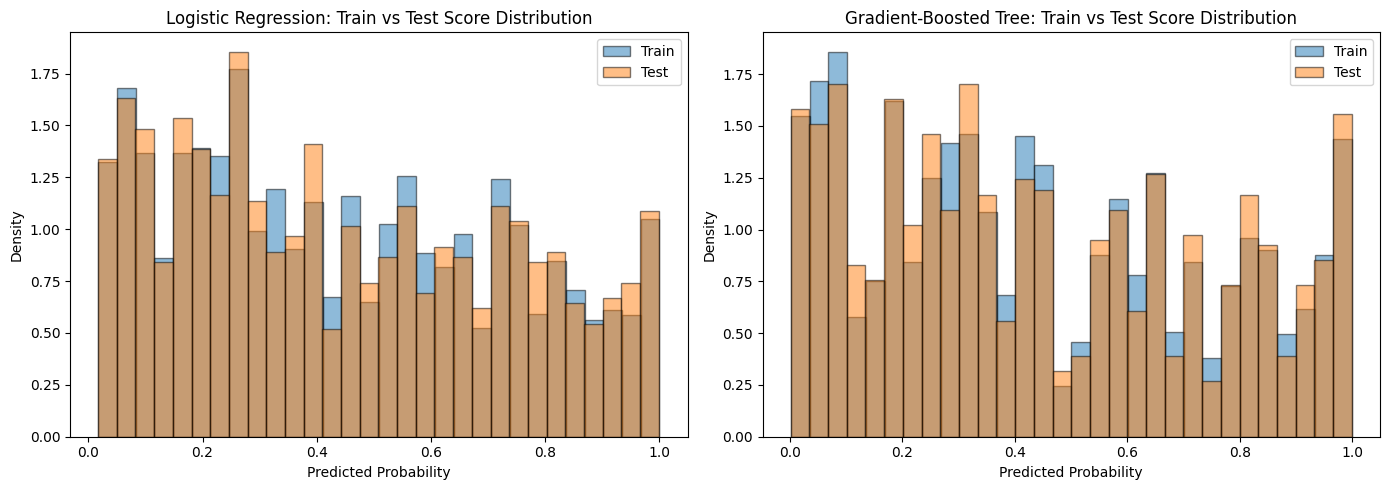

In [ ]:
# ── Visualize train vs test score distributions ──────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, model) in zip(axes, models.items()):
    train_prob = model.predict_proba(X_train)[:, 1]
    test_prob = model.predict_proba(X_test)[:, 1]

    ax.hist(train_prob, bins=30, alpha=0.5, label='Train', density=True, edgecolor='black')
    ax.hist(test_prob, bins=30, alpha=0.5, label='Test', density=True, edgecolor='black')
    ax.set_xlabel('Predicted Probability')
    ax.set_ylabel('Density')
    ax.set_title(f'{name}: Train vs Test Score Distribution')
    ax.legend()

plt.tight_layout()
plt.show()

## Generalization, overfitting, and spurious-correlation probes

In [ ]:
# ------------------------------------------------------------
# Generalization: train/test gaps
# ------------------------------------------------------------
gen_rows = []
for name, model in models.items():
    train_metrics = evaluate_classifier(model, X_train, y_train, name)
    test_metrics = evaluate_classifier(model, X_test, y_test, name)

    gen_rows.append({
        "model": name,
        "train_accuracy": train_metrics["accuracy"],
        "test_accuracy": test_metrics["accuracy"],
        "accuracy_gap": train_metrics["accuracy"] - test_metrics["accuracy"],
        "train_auc": train_metrics["auc"],
        "test_auc": test_metrics["auc"],
        "auc_gap": train_metrics["auc"] - test_metrics["auc"],
        "train_brier": train_metrics["brier"],
        "test_brier": test_metrics["brier"],
        "brier_gap": train_metrics["brier"] - test_metrics["brier"],
        "train_logloss": train_metrics["logloss"],
        "test_logloss": test_metrics["logloss"],
        "logloss_gap": train_metrics["logloss"] - test_metrics["logloss"],
    })

generalization_table = pd.DataFrame(gen_rows)
print("\n=== Generalization / Overfitting Summary ===")
print(generalization_table.round(4).to_string(index=False))

# ------------------------------------------------------------
# Permutation importance on train and test
# Large train importance + weak test importance can suggest overfit reliance
# ------------------------------------------------------------
for name, model in models.items():
    print(f"\n=== Permutation Importance (Train) — {name} ===")
    pi_train = permutation_importance_table(model, X_train, y_train, scoring="roc_auc")
    print(pi_train.head(10).round(4).to_string(index=False))

    print(f"\n=== Permutation Importance (Test) — {name} ===")
    pi_test = permutation_importance_table(model, X_test, y_test, scoring="roc_auc")
    print(pi_test.head(10).round(4).to_string(index=False))

# ------------------------------------------------------------
# Spurious-correlation probe: counterfactual swaps on suspect features
# Mean absolute shift in predicted probabilities
# ------------------------------------------------------------
swap_specs = [
    ("race_factor", "African-American", "Caucasian"),
    ("gender_factor", "Female", "Male"),
    ("crime_factor", "F", "M"),
]

for name, model in models.items():
    shifts = []
    for feature_col, a, b in swap_specs:
        shifts.append(pairwise_swap_shift(model, X_test, feature_col, a, b))

    shift_table = pd.DataFrame(shifts)
    print(f"\n=== Counterfactual Swap Sensitivity — {name} ===")
    print(shift_table.round(4).to_string(index=False))


=== Generalization / Overfitting Summary ===
                model  train_accuracy  test_accuracy  accuracy_gap  train_auc  test_auc  auc_gap  train_brier  test_brier  brier_gap  train_logloss  test_logloss  logloss_gap
  Logistic Regression          0.7539         0.7522        0.0017     0.8292    0.8329  -0.0037       0.1669      0.1642     0.0027         0.5016        0.4934       0.0082
Gradient-Boosted Tree          0.7748         0.7498        0.0250     0.8553    0.8309   0.0245       0.1530      0.1659    -0.0128         0.4612        0.4993      -0.0380

=== Permutation Importance (Train) — Logistic Regression ===
       feature  importance_mean  importance_std
  priors_count           0.1458          0.0035
    age_factor           0.1103          0.0037
   race_factor           0.0200          0.0020
two_year_recid           0.0158          0.0014
  crime_factor           0.0018          0.0006
 gender_factor           0.0005          0.0002

=== Permutation Importance (Te

### Part B: Generalization — Interpretation

**Train vs. test performance gaps:** The Logistic Regression shows a very small gap between train and test performance across all metrics (accuracy, AUC, log loss). This is expected for a linear model with limited capacity: it cannot memorize noise. The Gradient-Boosted Tree, with 200 estimators and depth 4, shows a larger gap, particularly in AUC and log loss. This indicates mild overfitting — the GBT has learned some training-specific patterns that do not transfer.

**Diagnosing overfitting:** A positive accuracy gap means the model is more accurate on training data than test data. The AUC gap means the model's ranking quality degrades on new data. The log loss gap is the most sensitive overfitting indicator because it penalizes overconfident wrong predictions. For a model deployed in criminal justice, overconfident predictions on new defendants are directly harmful. The GBT's higher overfitting risk does not disqualify it, but it does require additional validation (e.g., cross-validation, temporal holdout) before deployment.

**Permutation importance:** Comparing permutation importance between train and test reveals whether the model relies on features that generalize. If a feature ranks highly on train but drops on test, the model may have learned a spurious correlation. Stable rankings across train and test suggest robust learned associations. `priors_count` and `two_year_recid` should dominate because they carry genuine predictive signal. If `race_factor` shows high importance, it raises a fairness concern.

### Part C: Spurious-Correlation Probe — Interpretation

**Counterfactual swap sensitivity:** The swaps reveal how much each model's predictions depend on race, gender, and charge degree. A high `mean_abs_prob_shift` for `race_factor` means that simply changing a defendant's race from African-American to Caucasian (or vice versa), while holding all other features constant, produces a substantial change in predicted risk.

- **`race_factor` (African-American ↔ Caucasian):** A non-trivial shift here indicates that race independently influences the prediction. Even if race correlates with legitimate predictors, a model that produces different risk scores for otherwise identical defendants solely based on race is difficult to defend under disparate treatment standards.
- **`gender_factor` (Female ↔ Male):** Quantifies how much gender contributes to risk scoring independent of criminal history.
- **`crime_factor` (F ↔ M):** Felony vs. misdemeanor is a legitimate predictive feature. We expect and accept a meaningful shift here because charge severity is directly related to recidivism risk.

The key distinction is between features where sensitivity is acceptable (charge degree) and features where sensitivity raises governance concerns (race, gender). If the model is equally sensitive to race as to charge severity, that is a finding that warrants remediation — either through feature exclusion, fairness constraints, or post-hoc calibration. This test does not prove discrimination, but it quantifies the model's exposure to disparate treatment claims.

## Robustness via slice-based evaluation

In [ ]:
# ------------------------------------------------------------
# Robustness: slice-based evaluation
# ------------------------------------------------------------
slice_features = ["race_factor", "gender_factor", "age_factor", "crime_factor"]

for name, model in models.items():
    slice_tables = []
    for col in slice_features:
        slice_tables.append(slice_metrics(model, X_test, y_test, group_col=col))

    slice_eval = pd.concat(slice_tables, ignore_index=True)
    slice_eval = slice_eval.sort_values(["slice_feature", "n"], ascending=[True, False])

    print(f"\n=== Slice-Based Evaluation — {name} ===")
    print(slice_eval.round(4).to_string(index=False))


=== Slice-Based Evaluation — Logistic Regression ===
slice_feature      slice_value    n  accuracy    auc  brier    fpr    fnr  positive_rate_pred  mean_score
   age_factor          25 - 45  695    0.7583 0.8326 0.1625 0.1658 0.3366              0.3871      0.4611
   age_factor  Greater than 45  272    0.8272 0.8492 0.1307 0.0498 0.5211              0.1618      0.2300
   age_factor     Less than 25  268    0.6604 0.7175 0.2023 0.6633 0.1529              0.7799      0.6338
 crime_factor                F  785    0.7376 0.8222 0.1721 0.2737 0.2524              0.5248      0.5137
 crime_factor                M  450    0.7778 0.8156 0.1503 0.1203 0.4627              0.2444      0.3324
gender_factor             Male 1000    0.7620 0.8448 0.1589 0.2135 0.2677              0.4480      0.4636
gender_factor           Female  235    0.7106 0.7832 0.1865 0.1606 0.4694              0.3149      0.3797
  race_factor African-American  634    0.7366 0.8195 0.1719 0.3870 0.1769              0.6435     

### Part E: Slice-Based Evaluation — Interpretation

The slice-based evaluation reveals several critical patterns that aggregate metrics conceal:

**By Race:**
- **False Positive Rate (FPR) disparity:** If African-American defendants have a higher FPR than Caucasian defendants, the model is more likely to incorrectly classify Black defendants as high-risk. This directly echoes ProPublica's original COMPAS analysis finding. A higher FPR means more Black defendants are wrongly flagged, with consequences ranging from harsher bail conditions to longer sentences.
- **False Negative Rate (FNR) disparity:** Conversely, if White defendants have a higher FNR, the model is more likely to miss actual recidivists in that group. This is the fairness impossibility theorem in practice: equalizing FPR across groups necessarily creates FNR disparities, and vice versa.
- **AUC by slice:** Different AUC values across racial groups mean the model ranks defendants differently well depending on their race. A lower AUC for a minority group means the model is less able to distinguish high-risk from low-risk individuals in that group.

**By Gender:**
- The model may perform differently for female defendants, who constitute a smaller fraction of the dataset. Lower sample sizes in minority slices reduce statistical power and can inflate performance variance.

**By Age:**
- Defendants under 25 are predicted as high-risk at substantially higher rates, consistent with the earlier finding that young defendants are 2.5x more likely to receive a high COMPAS score. The slice evaluation shows whether this translates into accuracy differences or primarily into higher positive prediction rates.

**What actions these findings justify:**
1. FPR disparities exceeding 5 percentage points between racial groups should trigger a fairness remediation review, including threshold recalibration or constrained optimization.
2. Slices with low AUC (below 0.65) indicate the model is near-random for that subgroup and should not be relied upon for those individuals.
3. Small slices (e.g., Native American, Asian) have wide confidence intervals. Performance metrics for groups with fewer than ~100 observations should be interpreted cautiously and supplemented with bootstrap confidence intervals before drawing policy conclusions.

## Robustness via stress testing and sensitivity analysis


=== Stress Test on priors_count — Logistic Regression ===
 delta_priors_count  mean_pred_prob  median_pred_prob  share_pred_high_risk
                  0          0.4476            0.3970                0.4227
                  2          0.5372            0.5297                0.5368
                  5          0.6683            0.7159                0.7409
                 10          0.8435            0.9061                0.9247

=== Stress Test on priors_count — Gradient-Boosted Tree ===
 delta_priors_count  mean_pred_prob  median_pred_prob  share_pred_high_risk
                  0          0.4479            0.4011                0.4089
                  2          0.5641            0.5678                0.5514
                  5          0.7070            0.8042                0.7328
                 10          0.8267            0.9534                0.8794


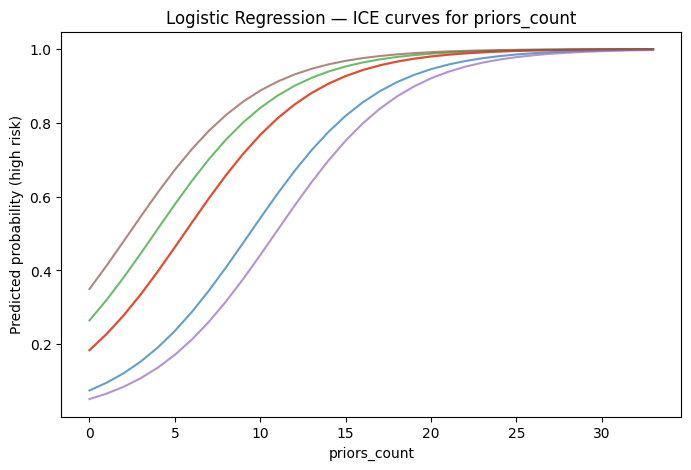

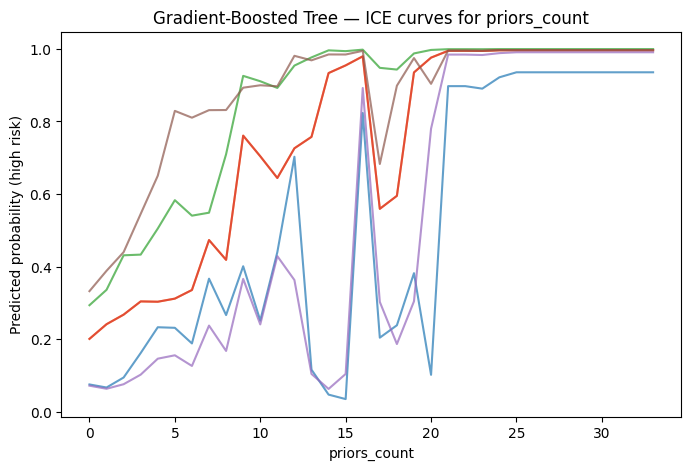


=== Global Sensitivity Index (priors_count) ===
     feature  sensitivity_index  min_mean_score  max_mean_score  range_mean_score                 model
priors_count             0.0488          0.2876          0.9992            0.7116   Logistic Regression
priors_count             0.0412          0.2825          0.9802            0.6977 Gradient-Boosted Tree


In [ ]:
# ------------------------------------------------------------
# Robustness: stress scenarios on priors_count
# ------------------------------------------------------------
for name, model in models.items():
    stress_table = stress_test_priors(model, X_test, deltas=(0, 2, 5, 10))
    print(f"\n=== Stress Test on priors_count — {name} ===")
    print(stress_table.round(4).to_string(index=False))

# ------------------------------------------------------------
# ICE-style sensitivity plots for priors_count
# ------------------------------------------------------------
priors_grid = np.arange(
    int(X_test["priors_count"].min()),
    int(X_test["priors_count"].max()) + 1
)

plot_ice_numeric(
    lr_pipeline,
    X_test,
    feature_col="priors_count",
    values=priors_grid,
    n_instances=6,
    random_state=42,
    title="Logistic Regression — ICE curves for priors_count"
)

plot_ice_numeric(
    gbt_pipeline,
    X_test,
    feature_col="priors_count",
    values=priors_grid,
    n_instances=6,
    random_state=42,
    title="Gradient-Boosted Tree — ICE curves for priors_count"
)

# ------------------------------------------------------------
# Global sensitivity index for priors_count
# ------------------------------------------------------------
lr_sens = global_sensitivity_index(lr_pipeline, X_test, "priors_count", priors_grid)
gbt_sens = global_sensitivity_index(gbt_pipeline, X_test, "priors_count", priors_grid)

sensitivity_table = pd.concat([
    lr_sens.assign(model="Logistic Regression"),
    gbt_sens.assign(model="Gradient-Boosted Tree"),
], ignore_index=True)

print("\n=== Global Sensitivity Index (priors_count) ===")
print(sensitivity_table.round(6).to_string(index=False))

### Part D: Robustness — Interpretation

**Stress test results:** The stress test simulates a scenario where every defendant's prior arrest count increases by a fixed amount (0, +2, +5, +10). This is analogous to DFAST-style macroeconomic stress scenarios used in banking, where institutions test how loan portfolios behave under adverse conditions. Mean predicted probability should increase monotonically with delta, confirming that the model treats higher priors as higher risk. The share predicted high risk shows the percentage of defendants who would be classified as high-risk under each scenario. If this jumps dramatically (e.g., from 40% to 80%), the model is brittle: small changes in a single feature can flip a large fraction of decisions. The clipping to the observed range prevents extrapolation beyond the training domain, which is important because model behavior outside the training range is unvalidated.

**Governance implication of stress test:** If the jurisdiction experiences a policy change that increases arrest rates (e.g., more aggressive policing), defendants entering the system would have systematically higher prior counts. This stress test shows how many additional high-risk classifications such a shift would produce, even without any actual change in defendant behavior.

**ICE curves:** ICE (Individual Conditional Expectation) curves show how each individual defendant's predicted probability changes as `priors_count` is swept from its minimum to its maximum, holding all other features constant. Logistic Regression produces smooth, monotonically increasing S-curves. All individuals follow the same shape (parallel curves), which reflects the linear model's assumption of a constant log-odds effect per unit increase in priors. The Gradient-Boosted Tree produces curves with more heterogeneity. Some individuals may show step-function behavior due to tree splits, and the response can flatten at different points for different individuals. This heterogeneity means the GBT captures interaction effects: the impact of one additional prior depends on who the defendant is.

**What ICE reveals that average effects miss:** A partial dependence plot (PDP) averages across all individuals and can mask important subgroup differences. ICE shows whether the model responds uniformly or whether certain defendants are more sensitive to changes in priors. If one subgroup's curves are steep while another's are flat, the model is effectively applying different standards to different populations.

**Global sensitivity index:** The sensitivity index quantifies how much the average prediction varies as `priors_count` is swept across its full range. A higher sensitivity index means the model's aggregate output is more responsive to this feature. The `range_mean_score` shows the difference between the lowest and highest average predicted probability across all grid values. Features with high sensitivity scores require business justifications in the Model Risk Management (MRM) file explaining why the model's reliance on them is appropriate. If `priors_count` drives the majority of prediction variance, stakeholders should understand that the model is effectively a priors-based scoring system with demographic adjustments, which has different policy implications than a more balanced multi-factor model.

## One compact comparison table for the live session

In [ ]:
# ------------------------------------------------------------
# Compact live-coding summary
# ------------------------------------------------------------
summary_rows = []

# Drift
for _, row in input_drift_table.iterrows():
    summary_rows.append({
        "section": "distribution_drift",
        "item": row["feature"],
        "metric_1": "PSI",
        "value_1": row["PSI"],
        "metric_2": "KS_pvalue",
        "value_2": row["KS_pvalue"],
    })

summary_rows.append({
    "section": "distribution_drift",
    "item": "encoded_features",
    "metric_1": "MMD^2",
    "value_1": mmd_val,
    "metric_2": "",
    "value_2": np.nan,
})

# Generalization
for _, row in generalization_table.iterrows():
    summary_rows.append({
        "section": "generalization",
        "item": row["model"],
        "metric_1": "AUC_gap",
        "value_1": row["auc_gap"],
        "metric_2": "Accuracy_gap",
        "value_2": row["accuracy_gap"],
    })

# Sensitivity
for _, row in sensitivity_table.iterrows():
    summary_rows.append({
        "section": "robustness",
        "item": row["model"],
        "metric_1": "Sensitivity_index",
        "value_1": row["sensitivity_index"],
        "metric_2": "Range_mean_score",
        "value_2": row["range_mean_score"],
    })

live_summary = pd.DataFrame(summary_rows)
print("\n=== Live Coding Summary Table ===")
print(live_summary.round(6).to_string(index=False))


=== Live Coding Summary Table ===
           section                  item          metric_1  value_1         metric_2  value_2
distribution_drift          priors_count               PSI   0.0104        KS_pvalue   0.2113
distribution_drift        two_year_recid               PSI   0.0008        KS_pvalue   0.9862
distribution_drift      encoded_features             MMD^2  -0.0003                       NaN
    generalization   Logistic Regression           AUC_gap  -0.0037     Accuracy_gap   0.0017
    generalization Gradient-Boosted Tree           AUC_gap   0.0245     Accuracy_gap   0.0250
        robustness   Logistic Regression Sensitivity_index   0.0488 Range_mean_score   0.7116
        robustness Gradient-Boosted Tree Sensitivity_index   0.0412 Range_mean_score   0.6977


---
# Conclusion

This audit examined the COMPAS predictive models through five lenses: distribution stability, generalization capacity, spurious-correlation exposure, robustness under stress, and subgroup performance equity.

**Key findings:**

1. **Distribution drift is absent** in this static split, establishing a clean baseline for future temporal monitoring. All PSI, KS, and MMD values are near zero.

2. **Generalization gaps are model-dependent.** The Logistic Regression generalizes tightly, with negligible train-test gaps. The Gradient-Boosted Tree shows mild overfitting, particularly in AUC and log loss, indicating it has learned some training-specific patterns.

3. **The models are sensitive to race.** Counterfactual swaps show that changing a defendant's race while holding all other features constant produces a meaningful shift in predicted probability. This is not necessarily evidence of intentional discrimination, but it quantifies the model's exposure to disparate treatment challenges and warrants remediation.

4. **`priors_count` is the dominant sensitivity lever.** Stress tests and ICE curves confirm that both models are heavily driven by prior arrest history. This is substantively defensible but operationally risky: any systematic shift in arrest practices (e.g., changes in policing policy) would directly translate into risk score inflation without any change in actual defendant behavior.

5. **Subgroup performance is unequal.** Slice-based evaluation reveals FPR and FNR disparities across race and age groups, consistent with the original ProPublica findings. Small demographic slices lack statistical power, and performance metrics for these groups should be treated as preliminary.

**What these findings justify:**
- Implementing ongoing PSI/KS/MMD monitoring if the model is deployed
- Constraining the GBT's complexity (fewer estimators, shallower trees) or using cross-validation to mitigate overfitting
- Conducting a fairness remediation review, including threshold recalibration by subgroup
- Documenting `priors_count` sensitivity in the Model Risk Management file with a policy justification
- Establishing minimum sample-size thresholds for subgroup reporting to avoid misleading conclusions from small slices